In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))


path = '/Volumes/Elements/PTM_project/PARK7/chainA_pY67/TYR_COORD_METAD_chainA_analysis_BF40/DATA_PLUMED/'



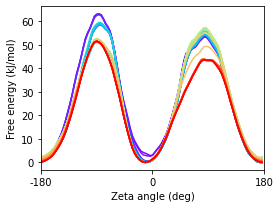

In [2]:
# time course convergence
T=298
sim=1

times = np.arange(220,1020,20)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

data = np.loadtxt(path+'COLVAR.{}'.format(sim))
CV = data[:,1]
rbias = data[:,4]

plt.figure(figsize = (4,3))


for t,c in zip(times,colors):
    
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    plt.plot(x[:-1],fel,color = c)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')
#plt.ylim(0,20)


plt.tight_layout()
plt.savefig('rbias_zeta_FEL_timecourse_sim{}.png'.format(sim))

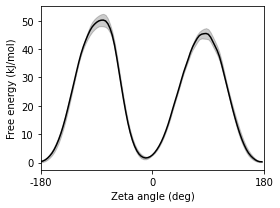

In [2]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,4]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_zeta.png')

In [3]:
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,4]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis.csv')
df

,Avg %,Err %
0,31.3,2.8


In [4]:
print(mu)
print(err)
print(cis_data)

[31.3]
[2.8000000000000003]
[0.3550348024880066, 0.244453581675398, 0.3383967357667165]


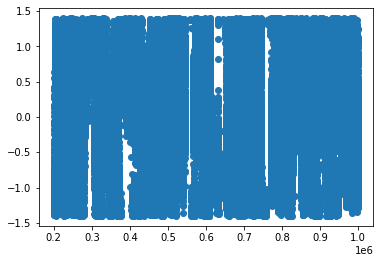

In [5]:
plt.scatter(data[:,0][init_frame:frame][cisframes],CV[init_frame:frame][cisframes])

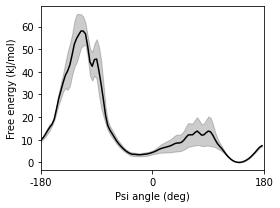

In [6]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,2]
    rbias = data[:,4]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Psi angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_psi.png')

In [7]:
# 2D FELs